In [1]:
!pip install qiskit qiskit-aer

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.3/9.3 MB 75.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.4/12.4 MB 84.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.4/2.4 MB 73.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 54.6/54.6 kB 3.6 MB/s eta 0:00:00


In [2]:
!pip install pylatexenc

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 162.6/162.6 kB 6.1 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for pylatexenc: filename=pylatexenc-2.10-py3-none-any.whl size=136817 sha256=a9a9af4d35fefdd733298e00bb25665e28168cc6002867221cf1179cf991c229
  Stored in directory: /root/.cache/pip/wheels/06/3e/78/fa1588c1ae991bbfd814af2bcac6cef7a178beee1939180d46
Successfully built pylatexenc


--- EJERCICIO 1: MOLÉCULA DE NH3 ---
Frecuencia natural (experimental): 24.79 GHz
Frecuencia de Rabi calculada (Hz): 22172850064.8879 Hz (22.1729 GHz)
Detuning angular (Delta): 6.9658e+10 rad/s


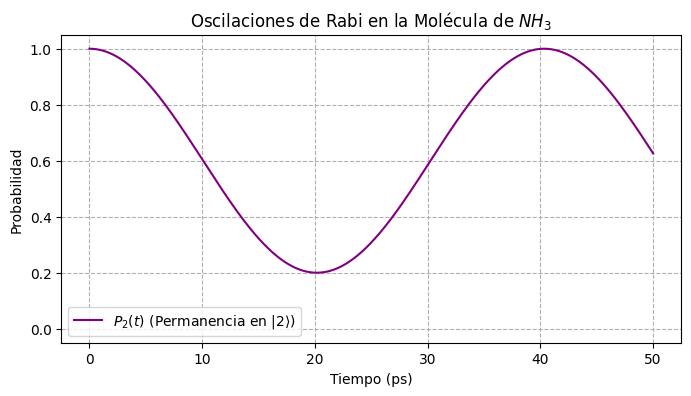


--- EJERCICIO 2: CIRCUITOS CUÁNTICOS Y ESTADOS DE BELL ---

1. Estado de Bell (2 Qubits):
     ┌───┐     ┌─┐   
q_0: ┤ H ├──■──┤M├───
     └───┘┌─┴─┐└╥┘┌─┐
q_1: ─────┤ X ├─╫─┤M├
          └───┘ ║ └╥┘
c: 2/═══════════╩══╩═
                0  1 
Resultados de la medición (Bell): {'00': 511, '11': 513}

2. Estado Entrelazado GHZ (3 Qubits):
     ┌───┐          ┌─┐      
q_0: ┤ H ├──■───────┤M├──────
     └───┘┌─┴─┐     └╥┘┌─┐   
q_1: ─────┤ X ├──■───╫─┤M├───
          └───┘┌─┴─┐ ║ └╥┘┌─┐
q_2: ──────────┤ X ├─╫──╫─┤M├
               └───┘ ║  ║ └╥┘
c: 3/════════════════╩══╩══╩═
                     0  1  2 
Resultados de la medición (GHZ 3-qubits): {'111': 512, '000': 512}

3. Estado Modificado con compuerta X(1) antes de medir:
     ┌───┐          ┌─┐        
q_0: ┤ H ├──■───────┤M├────────
     └───┘┌─┴─┐     └╥┘┌───┐┌─┐
q_1: ─────┤ X ├──■───╫─┤ X ├┤M├
          └───┘┌─┴─┐ ║ └┬─┬┘└╥┘
q_2: ──────────┤ X ├─╫──┤M├──╫─
               └───┘ ║  └╥┘  ║ 
c: 3/════════════════╩═══╩═══╩═
         

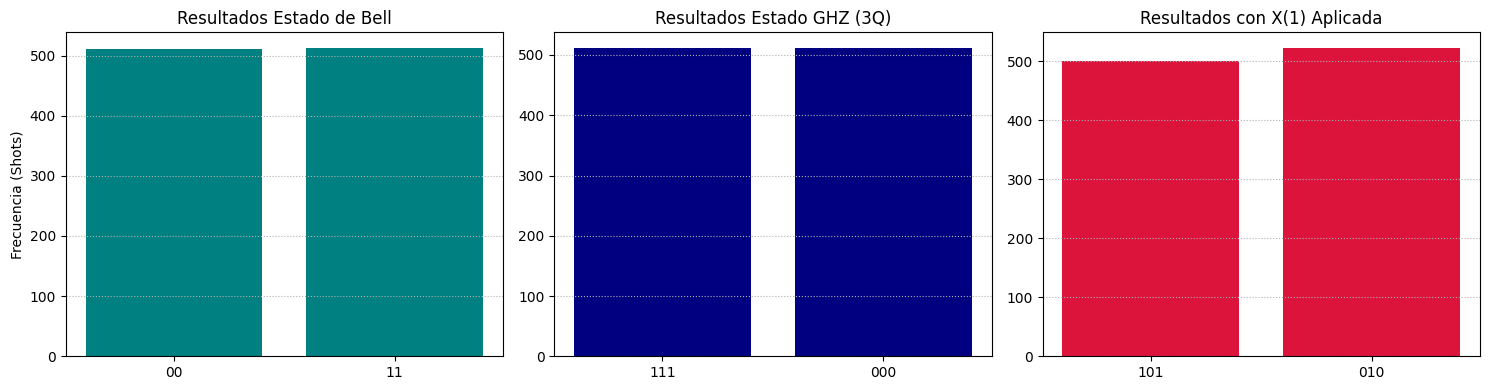

In [4]:
import numpy as np
import matplotlib.pyplot as plt

# EJERCICIO 1: Molécula de NH3 (Oscilaciones de Rabi)
print("--- EJERCICIO 1: MOLÉCULA DE NH3 ---")

#  Definición de Rutinas
def f_rabi_hz(delta_E_hz, detuning_factor):
    """
    Calcula la frecuencia de Rabi (en Hz) a partir de la separación de niveles
    experimental (f_natural) y una condición de detuning dada.
    Como f_natural = sqrt(f_Rabi^2 + detuning^2) y detuning = f_Rabi / 2:
    f_natural^2 = f_Rabi^2 + (f_Rabi / 2)^2 = (5/4) * f_Rabi^2
    f_Rabi = sqrt(4/5) * f_natural
    """
    return np.sqrt(4/5) * delta_E_hz

# Datos del enunciado
f_natural = 24.79e9  # Hz (24.79 GHz)
f_Rabi = f_rabi_hz(f_natural, 0.5)

# Frecuencias angulares correspondientes
Omega_R = 2 * np.pi * f_Rabi
Delta = Omega_R / 2
Omega_generalizada = np.sqrt(Omega_R**2 + Delta**2)

print(f"Frecuencia natural (experimental): {f_natural / 1e9:.2f} GHz")
print(f"Frecuencia de Rabi calculada (Hz): {f_Rabi:.4f} Hz ({f_Rabi / 1e9:.4f} GHz)")
print(f"Detuning angular (Delta): {Delta:.4e} rad/s")

#  Simulación en el tiempo (Probabilidad de permanencia en |2>)
# Dado que inicia en |2>, P2(t) es la probabilidad de quedarse en |2>
t = np.linspace(0, 5e-11, 1000)  # Ventana de tiempo en segundos (escala de picosegundos)

# Fórmula corregida de permanencia según las notas de clase
P2_t = 1 - (Omega_R / Omega_generalizada)**2 * np.sin(Omega_generalizada * t / 2)**2

# Graficación
plt.figure(figsize=(8, 4))
plt.plot(t * 1e12, P2_t, color='purple', label=r'$P_2(t)$ (Permanencia en $|2\rangle$)')
plt.title("Oscilaciones de Rabi en la Molécula de $NH_3$")
plt.xlabel("Tiempo (ps)")
plt.ylabel("Probabilidad")
plt.ylim(-0.05, 1.05)
plt.grid(True, linestyle='--')
plt.legend()
plt.show()


# EJERCICIO 2: Estado de Bell y Variaciones
print("\n--- EJERCICIO 2: CIRCUITOS CUÁNTICOS Y ESTADOS DE BELL ---")

from qiskit import QuantumCircuit
from qiskit_aer import AerSimulator

# Inicializar el simulador local para ejecutar los circuitos
simulador = AerSimulator()
shots = 1024

# PARTE 1: Circuito para Estado de Bell (2 qubits)
print("\n1. Estado de Bell (2 Qubits):")
qc_bell = QuantumCircuit(2, 2)
qc_bell.h(0)      # Superposición en Qubit 0
qc_bell.cx(0, 1)  # Entrelazamiento Qubit 0 -> Qubit 1
qc_bell.measure([0, 1], [0, 1])

# Mostrar Circuito
print(qc_bell.draw(output='text'))

# Ejecutar Simulación
resultado_bell = simulador.run(qc_bell, shots=shots).result()
conteos_bell = resultado_bell.get_counts()
print(f"Resultados de la medición (Bell): {conteos_bell}")


# PARTE 2: Agregar tercer qubit (Estado GHZ entrelazado de 3 qubits)
print("\n2. Estado Entrelazado GHZ (3 Qubits):")
qc_ghz = QuantumCircuit(3, 3)
qc_ghz.h(0)
qc_ghz.cx(0, 1)
qc_ghz.cx(1, 2)  # Entrelazar el tercer qubit
qc_ghz.measure([0, 1, 2], [0, 1, 2])

# Mostrar Circuito
print(qc_ghz.draw(output='text'))

# Ejecutar Simulación
resultado_ghz = simulador.run(qc_ghz, shots=shots).result()
conteos_ghz = resultado_ghz.get_counts()
print(f"Resultados de la medición (GHZ 3-qubits): {conteos_ghz}")


# PARTE 3: Desplazamiento de resultados agregando compuerta X(1)

print("\n3. Estado Modificado con compuerta X(1) antes de medir:")
qc_ghz_mod = QuantumCircuit(3, 3)
qc_ghz_mod.h(0)
qc_ghz_mod.cx(0, 1)
qc_ghz_mod.cx(1, 2)
qc_ghz_mod.x(1)   # Aplicamos compuerta NOT al qubit 1 al final del circuito
qc_ghz_mod.measure([0, 1, 2], [0, 1, 2])

# Mostrar Circuito
print(qc_ghz_mod.draw(output='text'))

# Ejecutar Simulación
resultado_mod = simulador.run(qc_ghz_mod, shots=shots).result()
conteos_mod = resultado_mod.get_counts()
print(f"Resultados de la medición modificada: {conteos_mod}")

# Graficación de los histogramas cuánticos para comparar los cambios (Shift)
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Histograma Bell
axes[0].bar(conteos_bell.keys(), conteos_bell.values(), color='teal')
axes[0].set_title("Resultados Estado de Bell")
axes[0].set_ylabel("Frecuencia (Shots)")

# Histograma GHZ
axes[1].bar(conteos_ghz.keys(), conteos_ghz.values(), color='navy')
axes[1].set_title("Resultados Estado GHZ (3Q)")

# Histograma Modificado
axes[2].bar(conteos_mod.keys(), conteos_mod.values(), color='crimson')
axes[2].set_title("Resultados con X(1) Aplicada")

for ax in axes:
    ax.grid(axis='y', linestyle=':')

plt.tight_layout()
plt.show()